Part 1  
Baseline before beauty  
TASK 01  
Load, explore, and define the target

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("diabetes_prediction_dataset.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (100000, 9)


In [2]:
# print 5 first rows
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
# print datatypes
print("Data Types:")
print(df.dtypes)

Data Types:
gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


In [4]:
# missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [5]:
# basic information
print("Basic Information")
df.info()

Basic Information
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [6]:
# Target definition/distribution
print("Our target column is diabetes")

print("\nTarget value counts:")
print(df['diabetes'].value_counts())
print("\nTarget proportions:")
print(df['diabetes'].value_counts(normalize=True))

Our target column is diabetes

Target value counts:
diabetes
0    91500
1     8500
Name: count, dtype: int64

Target proportions:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


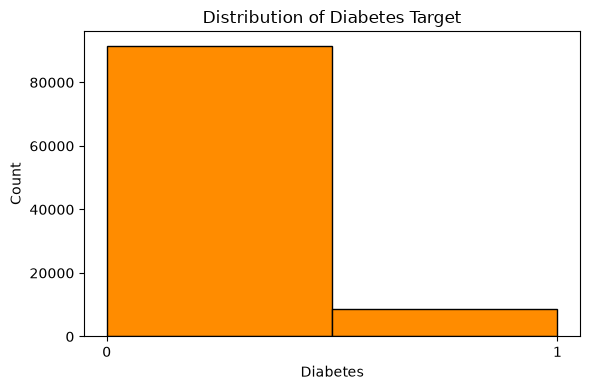

In [7]:
# Histogram of target
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df['diabetes'], bins=2, color="darkorange", edgecolor="black")
ax.set_title("Distribution of Diabetes Target")
ax.set_xlabel("Diabetes")
ax.set_ylabel("Count")
ax.set_xticks([0, 1])

plt.tight_layout()
plt.show()

TASK 02  
Make the train/test split once, and freeze the test set

In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['diabetes'])
y = df["diabetes"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (80000, 8)
X_test Shape: (20000, 8)
y_train Shape: (80000,)
y_test Shape: (20000,)


* Train: used for learning model parameters.
* Validation/CV: used for choosing/tuning models.
* Test: held out for the final evaluation only

TASK 03  
Build a dumb baseline first

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

baseline = DummyClassifier(
    strategy='most_frequent'
)

baseline_scores = cross_val_score(
    baseline, X_train, y_train, cv=5,
    scoring="accuracy"
)

baseline_cv = baseline_scores.mean()

print("Baseline CV Accuracy:", round(baseline_cv, 4))
print("Baseline fold scores:", baseline_scores)

Baseline CV Accuracy: 0.915
Baseline fold scores: [0.915 0.915 0.915 0.915 0.915]


* The DummyClassifier baseline achieved a 5-fold cross-validation accuracy of 91.5%. Since the baseline always predicts the majority class, this indicates that the target variable is highly imbalanced. Any trained model should therefore be evaluated against this baseline and with additional metrics beyond accuracy.

TASK 04  
One plain model, and feel the problem

In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Define categorical and numerical columns
cat_cols = [
    "gender",
    "smoking_history"
]

num_cols = [                 
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: ['gender', 'smoking_history']
Numerical Columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


In [11]:
# Create the encoder
# One Hot encode in categorical columns
# Preprocessing
prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"),
    cat_cols),
    ("num", StandardScaler(), num_cols)
])


# Plain Logistic regression pipeline
plain_lr = Pipeline([
    ("preprocessor", prep),
    ("model", LogisticRegression(max_iter=1000))
])


# 5 Fold cross validation
plain_scores = cross_val_score(
    plain_lr, X_train, y_train, cv=5,
    scoring='accuracy'
)

# mean cv accuracy
plain_cv = plain_scores.mean()
print("Plain Logistic Regression CV Accuracy:")
print(round(plain_cv, 3))
print("Plain LR fold scores:", plain_scores)

Plain Logistic Regression CV Accuracy:
0.96
Plain LR fold scores: [0.9601875 0.9614375 0.96025   0.9598125 0.9593125]


In [12]:
# Now fit it for inspect coefficients
plain_lr.fit(X_train, y_train)

print("Plain Logistic Regression Coefficients:")
print(plain_lr.named_steps["model"].coef_)

Plain Logistic Regression Coefficients:
[[-1.67836755 -1.38499393 -0.00978056 -1.04075432 -0.32905396 -0.34111602
  -0.42990128 -0.45275509 -0.47956136  1.02498324  0.2009559   0.14580888
   0.59205349  2.49029674  1.36182573]]


Part 2  
Regularised variants, tune, interpret, deliver  
TASK 05  
Add Ridge and Lasso, your next variants

In [13]:
# Scaled Preprocessor
from sklearn.preprocessing import StandardScaler

prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"),
    cat_cols),
    ("num", StandardScaler(), num_cols)
])

# L2 / Ridge-like model
# L2 Regression = Ridge-Like behaviour
l2_model = Pipeline([
    ("preprocessor", prep),
    ("model", LogisticRegression(
        penalty="l2", max_iter=1000,
        random_state=42
    ))
])

l2_scores = cross_val_score(
    l2_model, X_train, y_train, cv=5,
    scoring='accuracy'
)

l2_cv = l2_scores.mean()

print("L2 Logistic Regression CV Accuracy:")
print(round(l2_cv, 4))

/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

L2 Logistic Regression CV Accuracy:
0.9602


In [14]:
# L1- Lasso like model
# L1 regularisation = lasso-like feature selection
l1_model = Pipeline([
    ("preprocessor", prep),
    ("model", LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ))
])

l1_scores = cross_val_score(
    l1_model, X_train, y_train, cv=5,
    scoring='accuracy'
)

l1_cv = l1_scores.mean()

print("L1 Logistic Regression CV Accuracy:")
print(round(l1_cv, 4))

/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'pen

L1 Logistic Regression CV Accuracy:
0.9602


In [17]:
# compare the three model
comparison = pd.DataFrame({
    "Model": [
        "Baseline", "Plain Logistic Regression",
        "L2/Ridge Logistic Regression",
        "L1/Lasso Logistic Regression"
    ],
    "CV Accuracy":[
        baseline_cv, plain_cv,
        l2_cv, l1_cv
    ]
})

comparison

,Model,CV Accuracy
0,Baseline,0.9150
1,Plain Logistic Regression,0.9602
2,L2/Ridge Logistic Regression,0.9602
3,L1/Lasso Logistic Regression,0.9602


* Plain, L1, and L2 Logistic Regression all achieved the same CV accuracy of 0.9602, while the majority-class baseline achieved 0.9150. Therefore, all three Logistic Regression models substantially outperformed the baseline, but regularization did not improve accuracy over the plain model in this experiment.

* L1/Lasso Logistic Regression produces many exact zero coefficients because L1 regularization forces less-important coefficients all the way to zero, effectively selecting the more useful features.

TASK 06  
Tune your best regularised variant with cross-validation

In [21]:
# Tune L1 / Lasso Logistic Regression
from sklearn.linear_model import LogisticRegressionCV
tuned_l1 = Pipeline([
    ("preprocessor", prep),
    ("model", LogisticRegressionCV(
        Cs=[0.001, 0.01, 0.1, 1, 10, 100],
        cv=5, penalty="l1", solver='liblinear',
        max_iter=1000, random_state=42
    ))
])

# Fit on Training data
tuned_l1.fit(X_train, y_train)

# Get the selected C
best_C= tuned_l1.named_steps["model"].C_[0]

print("Best C:", best_C)

/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12

Best C: 0.01


In [22]:
# CV Score
tuned_scores = cross_val_score(
    tuned_l1, X_train, y_train,
    cv=5, scoring='accuracy'
)

tuned_cv = tuned_scores.mean()
print("Tuned L1/Lasso CV Accuracy:")
print(round(tuned_cv, 4))
print("\nFold scores:", tuned_scores)

/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12

Tuned L1/Lasso CV Accuracy:
0.9605

Fold scores: [0.960875  0.9614375 0.9605    0.960375  0.9595625]


In [24]:
# Count zero coefficients
tuned_coef = tuned_l1.named_steps["model"].coef_[0]

count = np.sum(np.isclose(tuned_coef, 0))

total_coef = len(tuned_coef)

print("Total Coefficient:", total_coef)
print("Zero Coefficient:", count)

Total Coefficient: 15
Zero Coefficient: 7


TASK 07  
Wrap it in one clean sklearn Pipeline

In [26]:
# Final clean pipeline
final_pipe = Pipeline([
    ("preprocessor", prep),
    ("model", LogisticRegressionCV(
        Cs=[0.001, 0.01, 0.1, 1, 10, 100],
        cv=5, penalty="l1", solver="liblinear",
        scoring='accuracy', max_iter=1000, random_state=42
    ))
])

print(final_pipe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'smoking_history']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'hypertension',
                                                   'heart_disease', 'bmi',
                                                   'HbA1c_level',
                                                   'blood_glucose_level'])])),
                ('model',
                 LogisticRegressionCV(Cs=[0.001, 0.01, 0.1, 1, 10, 100], cv=5,
                                      max_iter=1000, penalty='l1',
                                      random_state=42, scoring='accuracy',
                                      solver='liblinear'))])


In [27]:
# Run CV on the compelete pipeline
final_cv_scores = cross_val_score(
    final_pipe, X_train, y_train,
    cv=5, scoring='accuracy'
)

final_cv = final_cv_scores.mean()

print("Final Pipeline CV Accuracy:")
print(round(final_cv, 4))
print("\nPipeline fold scores:")
print(final_cv_scores)

/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12

Final Pipeline CV Accuracy:
0.9605

Pipeline fold scores:
[0.960875  0.9614375 0.9605    0.960375  0.9595625]


In [28]:
# Fit the final pipeline
final_pipe.fit(X_train, y_train)

print("Best C:", final_pipe.named_steps["model"].C_[0])

/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
/home/ctpc-29/Documents/Chirag-Internship/day1/myenv/lib/python3.12

Best C: 0.01


* The final Pipeline combines preprocessing and the tuned Logistic Regression model into a single workflow. Cross-validation is performed on the complete pipeline, so preprocessing is fitted separately within each training fold, preventing data leakage.

TASK 08  
Interpret the model, do not just report a number

In [29]:
# Extract features name
preprocessor = final_pipe.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()
print("Number of Features:", len(feature_names))
print("\nFeature Names:")
print(feature_names)

Number of Features: 15

Feature Names:
['cat__gender_Female' 'cat__gender_Male' 'cat__gender_Other'
 'cat__smoking_history_No Info' 'cat__smoking_history_current'
 'cat__smoking_history_ever' 'cat__smoking_history_former'
 'cat__smoking_history_never' 'cat__smoking_history_not current'
 'num__age' 'num__hypertension' 'num__heart_disease' 'num__bmi'
 'num__HbA1c_level' 'num__blood_glucose_level']


In [32]:
# Extract Coefficients
model = final_pipe.named_steps['model']
coef = model.coef_[0]
coef_df = pd.DataFrame({
    "Features": feature_names,
    "Coefficients": coef
})

coef_df["Absolute_Coefficient"] = (coef_df['Coefficients'].abs())

coef_df = coef_df.sort_values("Absolute_Coefficient", ascending=False)

coef_df

,Features,Coefficients,Absolute_Coefficient
13,num__HbA1c_level,2.183449,2.183449
14,num__blood_glucose_level,1.251980,1.251980
9,num__age,0.891956,0.891956
12,num__bmi,0.523865,0.523865
3,cat__smoking_history_No Info,-0.446887,0.446887
0,cat__gender_Female,-0.221495,0.221495
10,num__hypertension,0.187186,0.187186
11,num__heart_disease,0.136457,0.136457
6,cat__smoking_history_former,0.000000,0.000000
4,cat__smoking_history_current,0.000000,0.000000


In [42]:
# Top positive and negative features
print("Top Positive Features")
print("-" * 22)

top_posi = coef_df.sort_values("Coefficients", ascending=False).head(10)
print(top_posi)

print("\n\nTop Negative Features")
print("-" * 22)

top_neg = coef_df.sort_values("Coefficients", ascending=True).head(10)
print(top_neg)

Top Positive Features
----------------------
                        Features  Coefficients  Absolute_Coefficient
13              num__HbA1c_level      2.183449              2.183449
14      num__blood_glucose_level      1.251980              1.251980
9                       num__age      0.891956              0.891956
12                      num__bmi      0.523865              0.523865
10             num__hypertension      0.187186              0.187186
11            num__heart_disease      0.136457              0.136457
6    cat__smoking_history_former      0.000000              0.000000
1               cat__gender_Male      0.000000              0.000000
5      cat__smoking_history_ever      0.000000              0.000000
4   cat__smoking_history_current      0.000000              0.000000


Top Negative Features
----------------------
                            Features  Coefficients  Absolute_Coefficient
3       cat__smoking_history_No Info     -0.446887              0.446887
0  

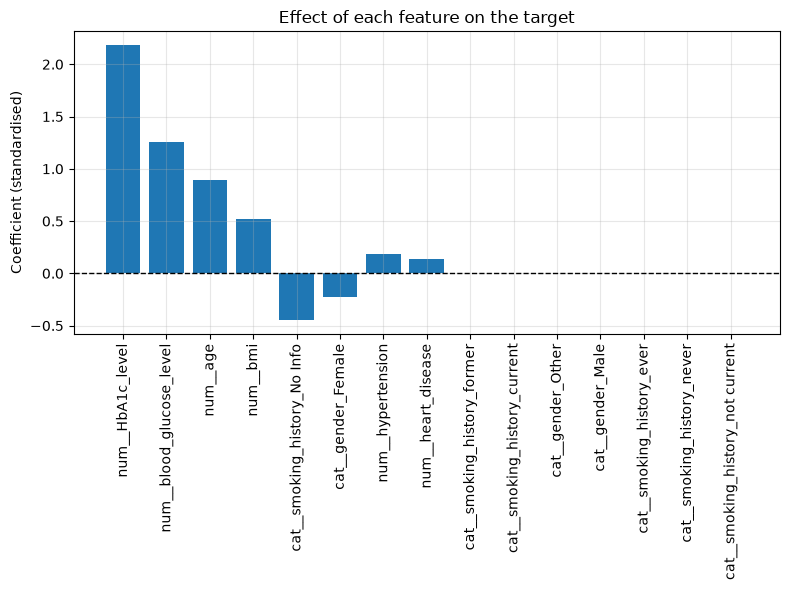

In [59]:
# Plot coefficients
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(coef_df["Features"], coef_df["Coefficients"])
ax.set_title("Effect of each feature on the target")
ax.set_ylabel("Coefficient (standardised)")
ax.axhline(y=0, lw=1, ls="--", color="black")
ax.tick_params(axis='x', rotation=90)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("coefficients.png", dpi=150, bbox_inches="tight")  # to save the picture
plt.show()

* Positive coefficients: Features with positive coefficients increase the likelihood of the target being 1, while negative coefficients decrease it.

* Most important features: Features with larger absolute coefficient values have a stronger influence on the prediction.

* Zero coefficients: Features whose coefficients are exactly 0 have been removed by Lasso, meaning the model considers them less useful for prediction.

TASK 09  
The final score, the comparison table, and the deliverable

In [60]:
# Final test evaluation
final_test_score = final_pipe.score(X_test, y_test)
print(f"Final test accuracy: {final_test_score:.4f}")

Final test accuracy: 0.9601


In [63]:
# Complete coparison table
comp_tab = pd.DataFrame({
    "model": ["Dummy Baseline", "Plain Logistic Regression",
             "L2/Ridge Logistic Regression", "L1/Lasso Logistic Regression",
             "Tuned L1 Pipeline"],
    "CV Accuracy": [
        baseline_cv, plain_cv, l2_cv, l1_cv,
        final_cv
    ],
    "Final Test Accuracy": [
        np.nan, np.nan, np.nan, np.nan,
        final_test_score
    ]
})

comp_tab["CV Accuracy"] = comp_tab["CV Accuracy"].round(4)
comp_tab["Final Test Accuracy"] = comp_tab["Final Test Accuracy"].round(4)

comp_tab

,model,CV Accuracy,Final Test Accuracy
0,Dummy Baseline,0.9150,NaN
1,Plain Logistic Regression,0.9602,NaN
2,L2/Ridge Logistic Regression,0.9602,NaN
3,L1/Lasso Logistic Regression,0.9602,NaN
4,Tuned L1 Pipeline,0.9605,0.9601


In [64]:
comp_tab.to_csv("comparison_table.csv", index=False)

In [73]:
# Final checks
print("Final Results")
print("-" * 14)

print(f"Baseline CV Accuracy            : {baseline_cv:.4f}")
print(f"Pain Logistic Regression CV     : {plain_cv:.4f}")
print(f"L2/Ridge Logistic Regression CV : {l2_cv:.4f}")
print(f"L1/Lasso Logistic Regression CV : {l1_cv:.4f}")
print(f"Tuned L1 Pipeline CV            : {final_cv:.4f}")
print(f"Final Test Accuracy             : {final_test_score:.4f}")
print(f"Best C                          : {final_pipe.named_steps['model'].C_[0]}")
print(f"Zero Coefficients               : {count}")

Final Results
--------------
Baseline CV Accuracy            : 0.9150
Pain Logistic Regression CV     : 0.9602
L2/Ridge Logistic Regression CV : 0.9602
L1/Lasso Logistic Regression CV : 0.9602
Tuned L1 Pipeline CV            : 0.9605
Final Test Accuracy             : 0.9601
Best C                          : 0.01
Zero Coefficients               : 7
